In [54]:
import os
import gc
import sys
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import multiprocessing as mp

In [62]:
# # To use PLUMBER2_GPP_common_utils, change directory to where it exists
# os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')
# from PLUMBER2_GPP_common_utils import *

import importlib

# Unload the module
if 'PLUMBER2_GPP_common_utils' in sys.modules:
    del sys.modules['PLUMBER2_GPP_common_utils']

# Reload the module
mymodule = importlib.import_module('PLUMBER2_GPP_common_utils')

# If you just want to reload without unloading:
importlib.reload(mymodule)
from PLUMBER2_GPP_common_utils import *

In [63]:
# Path of PLUMBER 2 dataset
PLUMBER2_path      = "/srv/ccrc/LandAP/z5218916/data/PLUMBER2/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"

site_names, IGBP_types, clim_types, model_names = load_default_list()

remove_site        = get_removed_site_names()

models_calc_LAI   = ['ORC2_r6593','ORC2_r6593_CO2','ORC3_r7245_NEE','ORC3_r8120','GFDL','SDGVM','QUINCY','NoahMPv401']
model_LAI_names   = {'ORC2_r6593':'lai','ORC2_r6593_CO2':'lai','ORC3_r7245_NEE':'lai','ORC3_r8120':'lai',
                     'GFDL':'lai', 'SDGVM':'lai','QUINCY':'LAI','NoahMPv401':'LAI'} #

# Calculate remaining sites
set_site_names      = set(site_names)
set_remove_site     = set(remove_site)
remain_sites        = set_site_names - set_remove_site
remain_sites        = list(remain_sites)

In [64]:
model_colors ={0:'red', 1: 'darkorange',2:'orange',3:'gold',4:'yellowgreen',5:'green',6:'mediumseagreen',
               7:'lime',8:'aquamarine',9:'cyan',10:'dodgerblue',11:'blue',12:'darkolivegreen',
               13:'forestgreen',14:'lime',15:'gold', 16:'orange',17:'pink',18:'pink',19:'red',20:'deeppink',
               21:'mediumorchid',22: 'darkviolet',}


In [65]:
def plot_characters(plot_type='IGBP'):
    
    df     = pd.read_csv(f'./txt/site_character.csv')
    colors = ['']*170
    
    if plot_type=='IGBP':
        type_colors  = set_IGBP_colors()
    elif plot_type=='clim_type':
        type_colors  = set_clim_colors()

    types = np.unique(df[plot_type])

    for t in types:
        colors = np.where(df[plot_type]==t, type_colors[t], colors)
        
    colors = np.where(df['site_name'].isin(remove_site), 'grey', colors)
        
    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(df['lon'], df['lat'], alpha=1, s=30, edgecolors=colors, facecolors='none', transform=ccrs.PlateCarree()) # 

    plt.title(f'{plot_type}')

    for t in types:
        ax.scatter([], [], edgecolors=type_colors[t], facecolors='none', alpha=1, s=30, label=f'{t}')
    
    ax.scatter([], [], edgecolors='grey', facecolors='none', alpha=1, s=30, label='unused')
    ax.legend(title='', loc='lower right', fontsize=10, ncols=5, frameon=False, labelspacing=0.3, handletextpad=0.1,borderpad=0.1)#, labelspacing=1.5, 


    # Zoomed-in plot for Europe
    ax_europe = plt.axes([0.13, 0.08, 0.20, 0.4], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_europe.set_extent([-12, 38, 34, 73], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_europe.coastlines()
    ax_europe.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_europe.add_feature(cfeature.LAND, facecolor='white')
    ax_europe.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_europe = ax_europe.scatter(df['lon'], df['lat'], alpha=1, s=30, edgecolors=colors, facecolors='none', transform=ccrs.PlateCarree())
    
    # Get the directory path
    directory = './plots/Global_map_site_characters'
    
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)
    plt.savefig(f'{directory}/Global_map_site_characters_{plot_type}.png',dpi=300)

    return

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


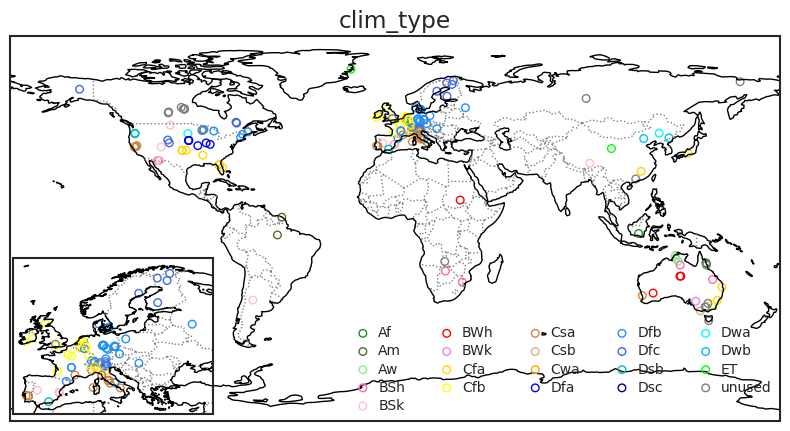

In [66]:
plot_characters(plot_type='clim_type')

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


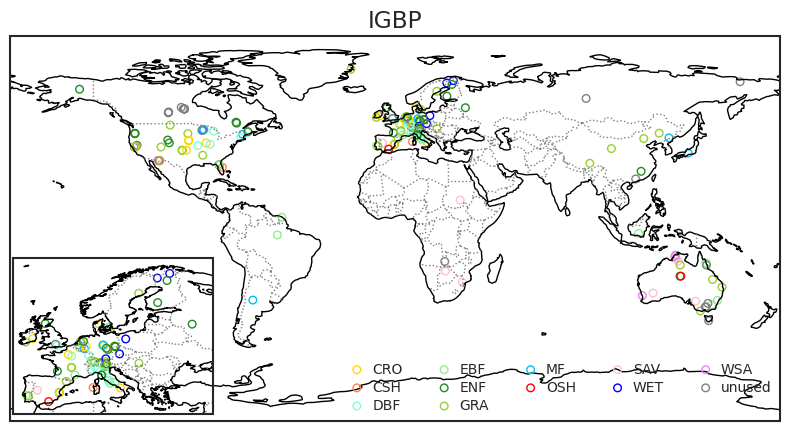

In [67]:
plot_characters(plot_type='IGBP')